## 1. Problem Statement

### Business Context

Diseases like Fusarium Rot, Leaf Blight and Mealy Bug Wilt pose a threat to pineapple production. Early diagnosis of these conditions can assist the grower to take timely action to prevent plant health and crop production being compromised.

To diagnose a disease in the field, the work requires the involvement of trained personnel. An image-based machine learning system could be an alternative way to screen pineapple leaves and classify the health condition of leaves using the pictures of the leaves.

### Machine Learning Problem

The goal of this project is to create an image classification model that will classify the state of a pineapple leaf based on an image.

It is a multi class classification problem containing four classes;

- Fusarium Rot
- Healthy
- Leaf Blight
- Mealy Bug Wilt

The choice of a convolutional neural network (CNN) was made because the data to be processed are images, and CNNs are able to extract visual patterns, like shapes, edges and textures, directly from the image's pixels.

### Project Objective

The primary goal is to design and test a basic CNN classification pipeline and investigate how changes to the model and training configurations affect validation results.

The best chosen model will then be tested on an unseen test set in order to estimate how well this model will perform on images that it has not seen during model selection.

## 2. Dataset and Data Exploration

### Dataset Description

The Pineapple Leaf Disease Dataset was downloaded from Zenodo. Includes field acquired images of leaves from four classes: Healthy Leaf, Mealybug Wilt, Fusarium Rot and Leaf Blight of pineapples.

The original images of this dataset were collected in Vazhakulam, Kerala, India, and there are 4,476 images in total. The photos were taken in the field with a variety of camera equipment.

The dataset has been chosen as it offers a good image classification problem for a pipeline utilizing a neural network and multiple images for each specimen.

Dataset source:

https://zenodo.org/records/21893516

In [12]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

from sklearn.metrics import confusion_matrix, classification_report

downloads_path = os.path.expanduser("~/Downloads/nn")

In [26]:
df = pd.read_csv(os.path.join(downloads_path, "Metadata_PineappleLeafdiseaseDataset.csv"))

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (4476, 15)


,Class,Specimen_ID,Image_Name,Health_Status,Temperature_C,Collection_Location,Device_Camera_Model,Image_Format,Width_pixels,Height_pixels,Resolution,File_Size_KB,Original_Image,Augmented,Remarks
0,Fusarium,Fusarium001,Fusarium001_01.jpg,Diseased,28,"Vazhakulam, Kerala, India",Redmi Note 14 5G,JPEG,4000,3000,4000 x 3000,3228.60,Yes,No,Original image
1,Fusarium,Fusarium001,Fusarium001_02.jpg,Diseased,28,"Vazhakulam, Kerala, Indiaa",Redmi Note 14 5G,JPEG,3000,4000,3000 x 4000,3007.10,Yes,No,Original image
2,Fusarium,Fusarium001,Fusarium001_03.jpg,Diseased,28,"Vazhakulam, Kerala, India",Redmi Note 14 5G,JPEG,3000,4000,3000 x 4000,2723.01,Yes,No,Original image
3,Fusarium,Fusarium001,Fusarium001_04.jpg,Diseased,28,"Vazhakulam, Kerala, Indiaa",Redmi Note 14 5G,JPEG,3000,4000,3000 x 4000,4532.42,Yes,No,Original image
4,Fusarium,Fusarium001,Fusarium001_05.jpg,Diseased,28,"Vazhakulam, Kerala, India",Redmi Note 14 5G,JPEG,3000,4000,3000 x 4000,5060.19,Yes,No,Original image


In [27]:
print("Dataset shape:", df.shape)

print("\nMissing values:", df.isnull().sum().sum())

print("Duplicate rows:", df.duplicated().sum())

print("\nClass distribution:")
print(df["Class"].value_counts())

Dataset shape: (4476, 15)

Missing values: 0
Duplicate rows: 0

Class distribution:
Fusarium Rot      1122
Healthy           1118
Leaf Blight       1112
Mealy Bug Wilt    1089
Fusarium            35
Name: Class, dtype: int64


In [28]:
df["Class"] = df["Class"].replace({"Fusarium": "Fusarium Rot"})

print(df["Class"].value_counts())

Fusarium Rot      1157
Healthy           1118
Leaf Blight       1112
Mealy Bug Wilt    1089
Name: Class, dtype: int64


In [29]:
class_paths = {
    "Fusarium Rot": os.path.join(downloads_path, "PLDD_Fusarium", "Fusarium"),
    "Healthy": os.path.join(downloads_path, "PLDD_Healthy", "Healthy"),
    "Leaf Blight": os.path.join(downloads_path, "PLDD_Leaf_Blight", "Leaf Blight"),
    "Mealy Bug Wilt": os.path.join(downloads_path, "PLDD_Mealy_bug_wilt", "Mealy bug wilt")
}

df["image_path"] = df.apply(
    lambda row: os.path.join(
        class_paths[row["Class"]],
        row["Specimen_ID"],
        row["Image_Name"]
    ),
    axis=1
)

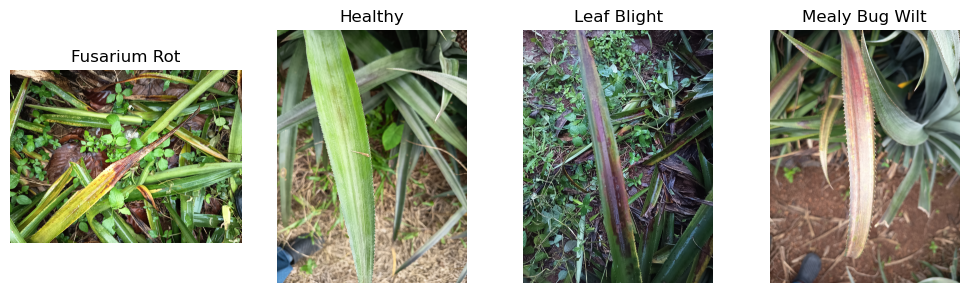

In [30]:
classes = ["Fusarium Rot", "Healthy", "Leaf Blight", "Mealy Bug Wilt"]

plt.figure(figsize=(10, 3))

for i, class_name in enumerate(classes):
    row = df[df["Class"] == class_name].iloc[0]

    image = Image.open(row["image_path"]).convert("RGB")

    plt.subplot(1, 4, i + 1)
    plt.imshow(image)
    plt.title(class_name)
    plt.axis("off")

plt.tight_layout()
plt.show()

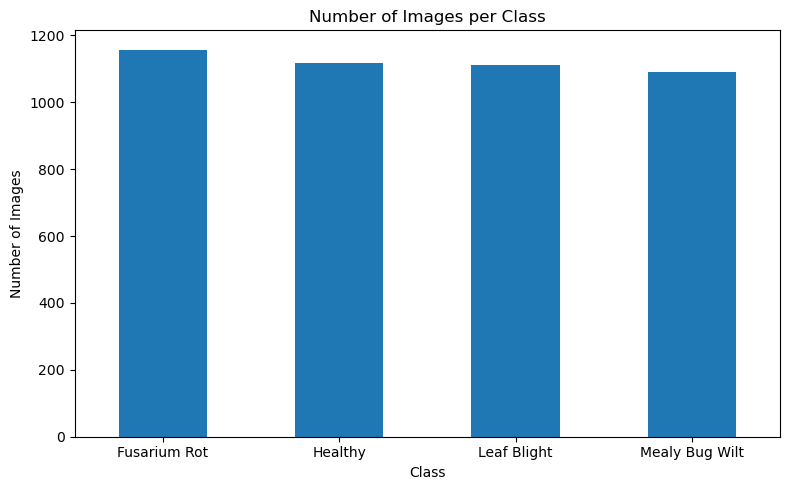

In [31]:
class_counts = df["Class"].value_counts()

plt.figure(figsize=(8, 5))
class_counts.plot(kind="bar")
plt.title("Number of Images per Class")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

#### Observations

- The representative images show clear visual differences between the four classes, including differences in leaf colour, texture and visible disease symptoms.
- The class distribution is relatively balanced, with each class containing a similar number of images. Therefore, no major class imbalance is present in the dataset.
- This balance allows accuracy to be used as the main evaluation metric, while precision, recall and F1-score can provide additional information about the performance of individual classes.

In [32]:
print("Unique specimens:", df["Specimen_ID"].nunique())

print("\nSpecimens per class:")
print(df.groupby("Class")["Specimen_ID"].nunique())

Unique specimens: 200

Specimens per class:
Class
Fusarium Rot      50
Healthy           50
Leaf Blight       50
Mealy Bug Wilt    50
Name: Specimen_ID, dtype: int64


In [33]:
images_per_specimen = df.groupby("Specimen_ID").size()

print("Average images per specimen:", round(images_per_specimen.mean(), 2))
print("Minimum images per specimen:", images_per_specimen.min())
print("Maximum images per specimen:", images_per_specimen.max())

Average images per specimen: 22.38
Minimum images per specimen: 20
Maximum images per specimen: 41


In [34]:
print("Camera devices:")
print(df["Device_Camera_Model"].value_counts())

Camera devices:
motorola edge 50 pro    2299
Redmi Note 14 5G        1319
Canon EOS 70D            858
Name: Device_Camera_Model, dtype: int64


### Dataset Splitting

Multiple images were collected from the same specimen. Therefore, the data was divided at the specimen level rather than at the individual image level. This helps prevent images of the same specimen from appearing in both training and test sets.

For each class, 20 specimens were used for training, 5 for validation and 5 for testing. The remaining specimens were not used in the experiment.

In [41]:
split_df = pd.read_csv(os.path.join(downloads_path, "pineapple_specimen_split.csv"))
print(split_df["Split"].value_counts())

train         80
validation    20
test          20
Name: Split, dtype: int64


In [40]:
df = df.merge(split_df,on="Specimen_ID",how="inner")

print(df["Split"].value_counts())

train         1796
test           441
validation     434
Name: Split, dtype: int64


In [42]:
train_ids = set(df[df["Split"] == "train"]["Specimen_ID"])
val_ids = set(df[df["Split"] == "validation"]["Specimen_ID"])
test_ids = set(df[df["Split"] == "test"]["Specimen_ID"])

print("Train & Validation overlap:", len(train_ids & val_ids))
print("Train & Test overlap:", len(train_ids & test_ids))
print("Validation & Test overlap:", len(val_ids & test_ids))

Train & Validation overlap: 0
Train & Test overlap: 0
Validation & Test overlap: 0


In [43]:
print(pd.crosstab(df["Class"], df["Split"]))

Split           test  train  validation
Class                                  
Fusarium Rot     108    456         107
Healthy          113    443         104
Leaf Blight      103    460         116
Mealy Bug Wilt   117    437         107


## 3. Data Preprocessing

The images need to be prepared before they can be used as input to the CNN. The preprocessing steps include loading the images, resizing them to a common size, normalising the pixel values and converting the class labels into numerical values.

In [44]:
train_df = df[df["Split"] == "train"].copy()
val_df = df[df["Split"] == "validation"].copy()
test_df = df[df["Split"] == "test"].copy()

print("Training images:", len(train_df))
print("Validation images:", len(val_df))
print("Test images:", len(test_df))

Training images: 1796
Validation images: 434
Test images: 441


In [45]:
IMG_SIZE = (128, 128)
classes = ["Fusarium Rot","Healthy","Leaf Blight","Mealy Bug Wilt"]

class_to_label = {name: i for i, name in enumerate(classes)}

print(class_to_label)

{'Fusarium Rot': 0, 'Healthy': 1, 'Leaf Blight': 2, 'Mealy Bug Wilt': 3}


In [50]:
def load_images(data):
    images = []
    labels = []

    for _, row in data.iterrows():
        image = Image.open(row["image_path"]).convert("RGB")
        image = image.resize(IMG_SIZE)
        image = np.array(image, dtype=np.float32) / 255.0
        images.append(image)
        labels.append(class_to_label[row["Class"]])

    return np.array(images), np.array(labels)

In [51]:
X_train, y_train = load_images(train_df)
X_val, y_val = load_images(val_df)
X_test, y_test = load_images(test_df)

print("Training:", X_train.shape, y_train.shape)

print("Validation:", X_val.shape, y_val.shape)

print("Test:", X_test.shape, y_test.shape)

C:\Users\HP\anaconda3\lib\site-packages\PIL\Image.py:3035: DecompressionBombWarning: Image size (108000000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


Training: (1796, 128, 128, 3) (1796,)
Validation: (434, 128, 128, 3) (434,)
Test: (441, 128, 128, 3) (441,)


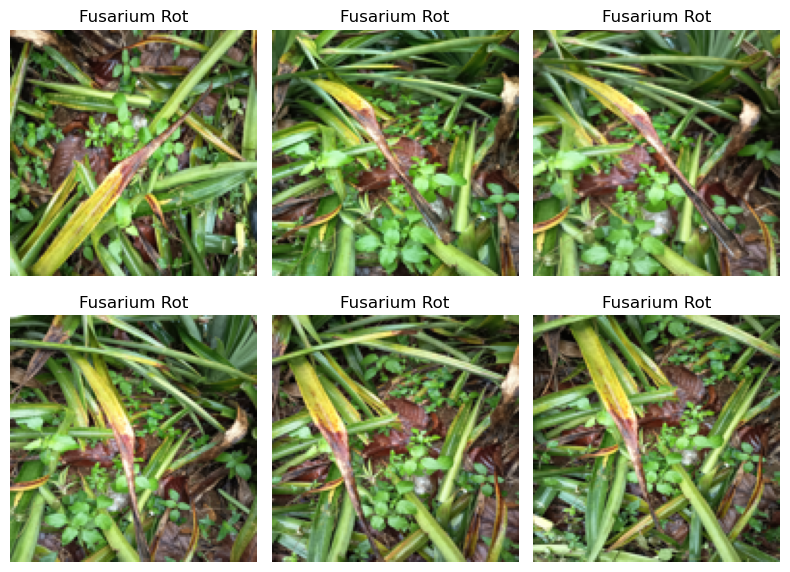

In [54]:
plt.figure(figsize=(8, 6))

for i in range(6):
    plt.subplot(2, 3, i + 1)
    plt.imshow(X_train[i])
    plt.title(classes[y_train[i]])
    plt.axis("off")

plt.tight_layout()
plt.show()

## 4. CNN Model Development

A convolutional neural network (CNN) was used because the input data consists of images. CNNs can learn spatial patterns such as edges, shapes and textures directly from image pixels.

A simple CNN architecture was chosen to keep the model understandable while providing enough capacity for the four-class classification task.

In [55]:
model = models.Sequential([layers.Input(shape=(128, 128, 3)),

    layers.Conv2D(32, (3, 3), activation="relu"),                     
    layers.MaxPooling2D((2, 2)),                           
    layers.Conv2D(64, (3, 3), activation="relu"),                           
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation="relu"),                           
    layers.MaxPooling2D((2, 2)),                          
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(4, activation="softmax")
])

model.compile(optimizer="adam",loss="sparse_categorical_crossentropy",metrics=["accuracy"])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 126, 126, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 63, 63, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 61, 61, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 30, 30, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 28, 28, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 14, 14, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 25088)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │       3,211,392 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 4)                   │             516 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,305,156 (12.61 MB)

 Trainable params: 3,305,156 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [56]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=15,
    batch_size=32,
    verbose=1
)

Epoch 1/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 33s 400ms/step - accuracy: 0.2449 - loss: 1.4657 - val_accuracy: 0.2834 - val_loss: 1.3401
Epoch 2/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 24s 427ms/step - accuracy: 0.3982 - loss: 1.2797 - val_accuracy: 0.3871 - val_loss: 1.1896
Epoch 3/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 24s 417ms/step - accuracy: 0.5512 - loss: 1.0972 - val_accuracy: 0.3848 - val_loss: 1.2638
Epoch 4/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 21s 366ms/step - accuracy: 0.6649 - loss: 0.8939 - val_accuracy: 0.4401 - val_loss: 1.1960
Epoch 5/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 21s 363ms/step - accuracy: 0.6988 - loss: 0.7528 - val_accuracy: 0.5276 - val_loss: 1.1220
Epoch 6/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 21s 363ms/step - accuracy: 0.7441 - loss: 0.6423 - val_accuracy: 0.5207 - val_loss: 1.1996
Epoch 7/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 21s 364ms/step - accuracy: 0.8111 - loss: 0.4916 - val_accuracy: 0.5161 - val_loss: 1.2593
Epoch 8/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 21s 362ms/step - accuracy: 0.8356 - loss: 0.4511 - val_accu

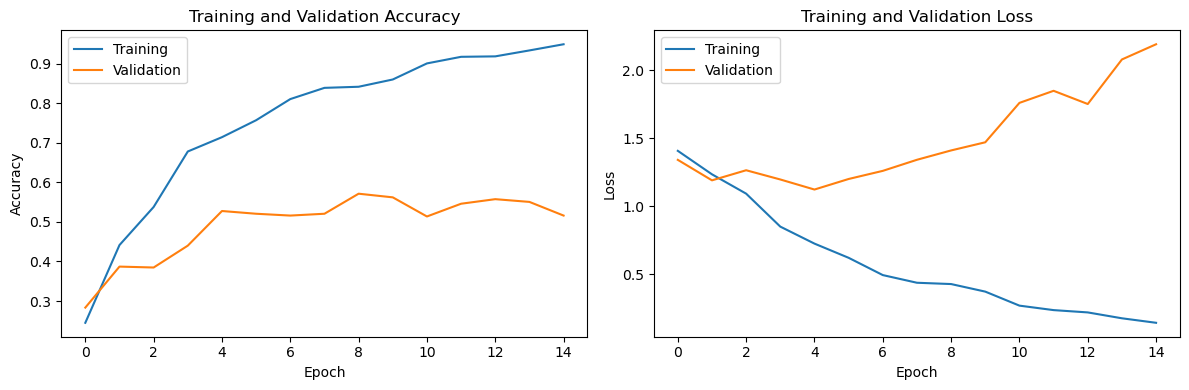

In [57]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Training")
plt.plot(history.history["val_accuracy"], label="Validation")
plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Training")
plt.plot(history.history["val_loss"], label="Validation")
plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()


plt.tight_layout()
plt.show()

### Observations

- Training accuracy increased substantially during the epochs, while validation accuracy improved less consistently.
- The difference between training and validation performance suggests that the model is overfitting to the training images.
- Therefore, different CNN configurations were compared to investigate whether validation performance could be improved.

## 5. Experiments and Model Selection

The baseline model showed a clear difference between training and validation performance, indicating overfitting. Therefore, ten CNN training configurations were compared to investigate whether changes to dropout, network size, filters, learning rate and batch size could improve validation performance.

Validation accuracy was used as the main metric for selecting the final model. The test set was kept unseen during these experiments.

In [49]:
def build_cnn(dropout_rate=0.5, dense_units=128,filter_scale=1, learning_rate=0.001):

    model = models.Sequential([
        layers.Input(shape=(128, 128, 3)),
        layers.Conv2D(int(32 * filter_scale), (3, 3), activation="relu"),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(int(64 * filter_scale), (3, 3), activation="relu"),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(int(128 * filter_scale), (3, 3), activation="relu"),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(dense_units, activation="relu"),
        layers.Dropout(dropout_rate),
        layers.Dense(4, activation="softmax")
    ])

    model.compile(
        optimizer=optimizers.Adam(learning_rate=learning_rate),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    
    
    return model

In [50]:
def run_experiment(name, dropout_rate=0.5, dense_units=128, filter_scale=1,
                   learning_rate=0.001, batch_size=32):

    tf.keras.backend.clear_session()

    experiment_model = build_cnn(
        dropout_rate=dropout_rate,
        dense_units=dense_units,
        filter_scale=filter_scale,
        learning_rate=learning_rate
    )

    experiment_history = experiment_model.fit(
        X_train,
        y_train,
        validation_data=(X_val, y_val),
        epochs=12,
        batch_size=batch_size,
        verbose=0
    )

    best_val_accuracy = max(
        experiment_history.history["val_accuracy"]
    )

    best_val_loss = min(
        experiment_history.history["val_loss"]
    )

    return {
        "Experiment": name,
        "Best Validation Accuracy": best_val_accuracy,
        "Best Validation Loss": best_val_loss
    }

In [51]:
experiments = []

experiments.append(run_experiment("Baseline"))

experiments.append(run_experiment("Dropout 0.3",dropout_rate=0.3))

experiments.append(run_experiment("Dropout 0.7",dropout_rate=0.7))

experiments.append(run_experiment("Dense 64",dense_units=64))

experiments.append(run_experiment("Smaller Filters",filter_scale=0.5))

experiments.append(run_experiment("Batch Size 64",batch_size=64))

experiments.append(run_experiment("Learning Rate 0.0001",learning_rate=0.0001))

experiments.append(run_experiment("Dense 256",dense_units=256))

experiments.append(run_experiment("Dropout 0.4",dropout_rate=0.4))

experiments.append(run_experiment("Dropout 0.6",dropout_rate=0.6))

results = pd.DataFrame(experiments)

results

,Experiment,Best Validation Accuracy,Best Validation Loss
0,Baseline,0.589862,1.041903
1,Dropout 0.3,0.536866,1.403106
2,Dropout 0.7,0.564516,1.277976
3,Dense 64,0.592166,1.156558
4,Smaller Filters,0.592166,1.068281
5,Batch Size 64,0.594470,1.140791
6,Learning Rate 0.0001,0.536866,1.046310
7,Dense 256,0.592166,0.979431
8,Dropout 0.4,0.585253,1.242848
9,Dropout 0.6,0.580645,1.103688


### Observations

- Batch Size 64 achieved the highest validation accuracy of **59.45%** among the ten experiments.
- Changes to dropout, filter size, dense-layer size, and learning rate did not improve the validation accuracy beyond this result.

In [52]:
best_experiment = results.loc[results["Best Validation Accuracy"].idxmax()]

print("Best experiment:")
print(best_experiment)

Best experiment:
Experiment                  Batch Size 64
Best Validation Accuracy          0.59447
Best Validation Loss             1.140791
Name: 5, dtype: object


## 6. Final Model Assessment

The selected CNN configuration was retrained using the training data, with the validation set used to monitor validation performance. The model with the best validation accuracy was saved and then evaluated on the unseen test set.

In [55]:
final_model = build_cnn(dropout_rate=0.5,dense_units=128,
    filter_scale=1,learning_rate=0.001
)

checkpoint = ModelCheckpoint(
    "best_pineapple_cnn.keras",
    monitor="val_accuracy",
    mode="max",
    save_best_only=True
)

final_history = final_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=15,
    batch_size=64,
    callbacks=[checkpoint],
    verbose=1
)

Epoch 1/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 224s 2s/step - accuracy: 0.2705 - loss: 1.4815 - val_accuracy: 0.3410 - val_loss: 1.3599
Epoch 2/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 25s 845ms/step - accuracy: 0.3600 - loss: 1.3361 - val_accuracy: 0.4101 - val_loss: 1.2850
Epoch 3/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 24s 768ms/step - accuracy: 0.4993 - loss: 1.1604 - val_accuracy: 0.4309 - val_loss: 1.3764
Epoch 4/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 23s 781ms/step - accuracy: 0.6031 - loss: 0.9411 - val_accuracy: 0.4747 - val_loss: 1.4013
Epoch 5/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 25s 876ms/step - accuracy: 0.6505 - loss: 0.8835 - val_accuracy: 0.5000 - val_loss: 1.2541
Epoch 6/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 24s 829ms/step - accuracy: 0.7472 - loss: 0.6749 - val_accuracy: 0.5576 - val_loss: 1.2344
Epoch 7/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 25s 871ms/step - accuracy: 0.7475 - loss: 0.6491 - val_accuracy: 0.5691 - val_loss: 1.1641
Epoch 8/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 25s 846ms/step - accuracy: 0.8147 - loss: 0.4905 - val_accura

In [56]:
best_model = tf.keras.models.load_model("best_pineapple_cnn.keras")

test_loss, test_accuracy = best_model.evaluate(
    X_test,
    y_test,
    verbose=1
)

print("Test Loss:", round(test_loss, 4))
print("Test Accuracy:", round(test_accuracy, 4))

14/14 ━━━━━━━━━━━━━━━━━━━━ 15s 554ms/step - accuracy: 0.5544 - loss: 1.5670
Test Loss: 1.1091
Test Accuracy: 0.6848


### Test Set Results

The final CNN achieved an accuracy of **68.48%** on the unseen test set, with a test loss of **1.1091**. The test set was not used during model selection or training, providing an independent assessment of the final model's performance.

In [57]:
y_pred_prob = best_model.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_prob, axis=1)

print("Predictions generated successfully.")

Predictions generated successfully.


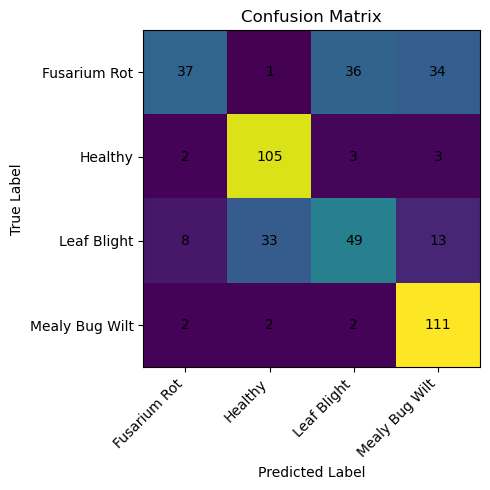

In [58]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))
plt.imshow(cm)

plt.xticks(
    range(len(classes)),
    classes,
    rotation=45,
    ha="right"
)
plt.yticks(
    range(len(classes)),
    classes
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

for i in range(len(classes)):
    for j in range(len(classes)):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
plt.show()

In [59]:
print(classification_report(
    y_test,
    y_pred,
    target_names=classes
))

                precision    recall  f1-score   support

  Fusarium Rot       0.76      0.34      0.47       108
       Healthy       0.74      0.93      0.83       113
   Leaf Blight       0.54      0.48      0.51       103
Mealy Bug Wilt       0.69      0.95      0.80       117

      accuracy                           0.68       441
     macro avg       0.68      0.67      0.65       441
  weighted avg       0.69      0.68      0.66       441



### Classification Results

- The model performed well for **Healthy** and **Mealy Bug Wilt**, with recall values of **0.93** and **0.95**, respectively.
- **Fusarium Rot** and **Leaf Blight** were more difficult to classify, with lower recall values of **0.34** and **0.48**. This shows that the model still confuses some disease classes.

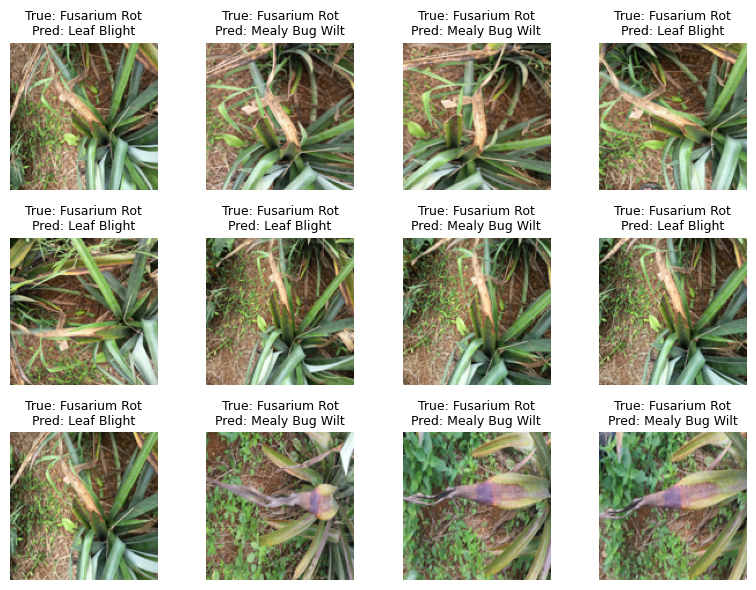

Total incorrect predictions: 139


In [61]:
incorrect_indices = np.where(y_pred != y_test)[0]

plt.figure(figsize=(8, 6))

for i, index in enumerate(incorrect_indices[:12]):
    plt.subplot(3, 4, i + 1)

    plt.imshow(X_test[index])

    true_label = classes[y_test[index]]
    predicted_label = classes[y_pred[index]]

    plt.title(
        f"True: {true_label}\nPred: {predicted_label}",
        fontsize=9
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

print("Total incorrect predictions:", len(incorrect_indices))

### Error Analysis

The misclassified images indicate that the majority of the errors are made between the disease classes. Sometimes, Fusarium Rot gets confused with Leaf Blight and Mealy Bug Wilt, and some Leaf Blight images are predicted as other classes. This indicates that there are some disease categories that are hard for the CNN to differentiate visually.

## 7. Discussion

### Strengths and Limitations

The main advantage of the project is that the CNN can learn visual patterns directly from pineapple leaf images without manually selecting image features. The model can classify the images into four different health conditions. The specimen-level split also reduces the possibility of images from the same specimen appearing in both training and testing data.

There are, however, some drawbacks to the model. The accuracy of the test was 68.48%, whereas the Fusarium Rot and Leaf Blight were more challenging to classify as reflected by the confusion matrix. The images also were captured in the field, which can introduce background variation, camera and lighting changes that can impact predictions. The model should thus be used as a screening tool and not as a substitute for a professional evaluation.

### Business Implications

This type of model can be used to assist farmers or agricultural workers in giving them an initial indication of possible leaf disease from pictures. This may help the identification of plants that need to be examined and help to concentrate on areas that could be affected.

### Informative Visual Patterns and Explainability

The CNN is trained on visual patterns like edges, shapes, colour changes and textures of leaf images. The confusion matrix and error analysis offer a straightforward approach to overcoming the problem of understanding which classes are more or less easily separated by the model. In future, more sophisticated methods of explainability could be employed to detect image regions that are contributing to the prediction.

### Recommendations and Deployment

The model should be validated using a larger number of field images that cover a wider range of locations, cameras and environment before its practical deployment. Other enhancements may include gathering additional examples of the disease classes that were often misclassified. One potential application may be to upload an image of a pineapple leaf and have an initial screening prediction of the class returned.

## 8. Conclusion

This project aimed to create a CNN based image classification system for distinguishing between four conditions of pineapple leaves (Fusarium Rot, Healthy, Leaf Blight and Mealy Bug Wilt). The images were preprocessed by resizing them to 128 × 128 pixels and normalizing the image values.

The number of CNN configurations tested is 10, with the highest validation accuracy of 59.45% achieved by the Batch Size 64 configuration. The selected model achieved a test accuracy of 68.48% on the unseen test set.

The results indicate that images of Healthy and Mealy Bug Wilt images could be identified relatively well, whereas Fusarium Rot and Leaf Blight images were more difficult to be distinguished. In conclusion, the model showcases the potential application of CNNs in the classification of pineapple leaf diseases, and further research and testing would be necessary to integrate this technology into real-time systems for use in the field.

## 9. References

Raj, S., Prakash, N. and Malik, N. (2026) *Pineapple Leaf Disease Dataset: Field-Acquired Images for Deep Learning-Based Plant Health Assessment*. Zenodo. Available at: https://zenodo.org/records/21893516

Abadi, M. et al. (2016) ‘TensorFlow: A system for large-scale machine learning’, *Proceedings of the 12th USENIX Symposium on Operating Systems Design and Implementation*, pp. 265–283.

Chollet, F. (2015) *Keras*. Available at: https://keras.io/

Pedregosa, F. et al. (2011) ‘Scikit-learn: Machine Learning in Python’, *Journal of Machine Learning Research*, 12, pp. 2825–2830.